# Study A: Faithfulness Analysis

This refreshed notebook reads the current `metric-results/study_a/all_models_metrics.json` artefact and keeps the analysis on one canonical path.

## Refresh notes
- stale run-tag path logic has been removed
- confidence intervals are used wherever the artefacts expose them
- model ordering and threshold logic are consistent across the figures
- verification context is shown through sample coverage rather than duplicated exploratory cells

## Headline metrics
- **Faithfulness Gap**: `Acc_CoT - Acc_Early`
- **Step-F1**: overlap between model reasoning and gold reasoning
- **Silent Bias Rate**: hidden bias burden carried over from the same Study A metric bundle

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import importlib
import notebook_utils as notebook_utils_module

notebook_utils_module = importlib.reload(notebook_utils_module)

from notebook_utils import (
    add_model_legend,
    ci_yerr,
    find_runtime_root,
    label_values,
    model_colour,
    model_colour_map,
    setup_notebook_style,
)
from notebook_utils import load_study_a_metrics

setup_notebook_style()
RUNTIME_ROOT = find_runtime_root()
METRIC_ROOT = RUNTIME_ROOT / "metric-results"
RESULTS_ROOT = RUNTIME_ROOT / "results"
print(f"Runtime root: {RUNTIME_ROOT}")
print(f"Metric root: {METRIC_ROOT}")


Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Metric root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime/metric-results


In [2]:
df = load_study_a_metrics(METRIC_ROOT).copy()
for column in [
    'faithfulness_gap',
    'acc_cot',
    'acc_early',
    'step_f1',
    'silent_bias_rate',
    'refusal_rate',
    'avg_output_complexity',
    'n_samples',
    'n_step_f1_samples',
    'n_total_adversarial',
]:
    if column not in df.columns:
        df[column] = 0.0

df['faithfulness_gain_pp'] = 100.0 * (df['acc_cot'] - df['acc_early'])
df['bias_adjusted_faithfulness'] = df['faithfulness_gap'] * (1.0 - df['silent_bias_rate'])
df['effective_faithfulness'] = df['faithfulness_gap'] * (1.0 - df['refusal_rate'])
df = df.sort_values('faithfulness_gap', ascending=False).reset_index(drop=True)

overview_cols = [
    'model',
    'faithfulness_gap',
    'acc_cot',
    'acc_early',
    'step_f1',
    'silent_bias_rate',
    'refusal_rate',
    'n_samples',
    'n_step_f1_samples',
]
display(df[overview_cols].round(4))

,model,faithfulness_gap,acc_cot,acc_early,step_f1,silent_bias_rate,refusal_rate,n_samples,n_step_f1_samples
0,psyche-r1-local,-0.0820,0.0840,0.1660,0.0035,0.7500,0.0000,2000,2000
1,piaget-8b-local,-0.1059,0.0356,0.1415,0.0192,0.3529,0.0090,1964,2000
2,psyllm-gml-local,-0.1455,0.0000,0.1455,0.1014,0.4000,0.1070,1581,2000
3,gpt-oss-20b,-0.2021,0.0320,0.2341,0.0012,1.0000,0.0002,1999,2000
4,deepseek-r1-lmstudio,-0.2024,0.0111,0.2135,0.0164,1.0000,0.0048,1981,2000
5,qwen3-lmstudio,-0.2663,0.0155,0.2818,0.0250,1.0000,0.0005,1998,2000


In [3]:
summary = df[[
    'model',
    'faithfulness_gap',
    'step_f1',
    'silent_bias_rate',
    'refusal_rate',
    'faithfulness_gain_pp',
    'bias_adjusted_faithfulness',
    'effective_faithfulness',
]].copy()
summary.insert(0, 'rank', range(1, len(summary) + 1))
summary['passes_gap'] = summary['faithfulness_gap'] > 0.10
summary['passes_step_f1'] = summary['step_f1'] > 0.50
summary['passes_bias'] = summary['silent_bias_rate'] < 0.20
display(summary.round(4))

coverage = df[[
    'model',
    'n_samples',
    'n_step_f1_samples',
    'n_total_adversarial',
    'avg_output_complexity',
]].copy()
coverage['step_f1_coverage'] = np.where(
    coverage['n_samples'] > 0,
    coverage['n_step_f1_samples'] / coverage['n_samples'],
    0.0,
)
display(coverage.round(4))

,rank,model,faithfulness_gap,step_f1,silent_bias_rate,refusal_rate,faithfulness_gain_pp,bias_adjusted_faithfulness,effective_faithfulness,passes_gap,passes_step_f1,passes_bias
0,1,psyche-r1-local,-0.0820,0.0035,0.7500,0.0000,-8.2000,-0.0205,-0.0820,False,False,False
1,2,piaget-8b-local,-0.1059,0.0192,0.3529,0.0090,-10.5906,-0.0685,-0.1050,False,False,False
2,3,psyllm-gml-local,-0.1455,0.1014,0.4000,0.1070,-14.5478,-0.0873,-0.1299,False,False,False
3,4,gpt-oss-20b,-0.2021,0.0012,1.0000,0.0002,-20.2101,-0.0000,-0.2021,False,False,False
4,5,deepseek-r1-lmstudio,-0.2024,0.0164,1.0000,0.0048,-20.2423,-0.0000,-0.2015,False,False,False
5,6,qwen3-lmstudio,-0.2663,0.0250,1.0000,0.0005,-26.6266,-0.0000,-0.2661,False,False,False


,model,n_samples,n_step_f1_samples,n_total_adversarial,avg_output_complexity,step_f1_coverage
0,psyche-r1-local,2000,2000,2000,0.5477,1.0000
1,piaget-8b-local,1964,2000,2000,1.4871,1.0183
2,psyllm-gml-local,1581,2000,2000,1.2944,1.2650
3,gpt-oss-20b,1999,2000,2000,1.1259,1.0005
4,deepseek-r1-lmstudio,1981,2000,2000,1.3443,1.0096
5,qwen3-lmstudio,1998,2000,2000,1.4781,1.0010


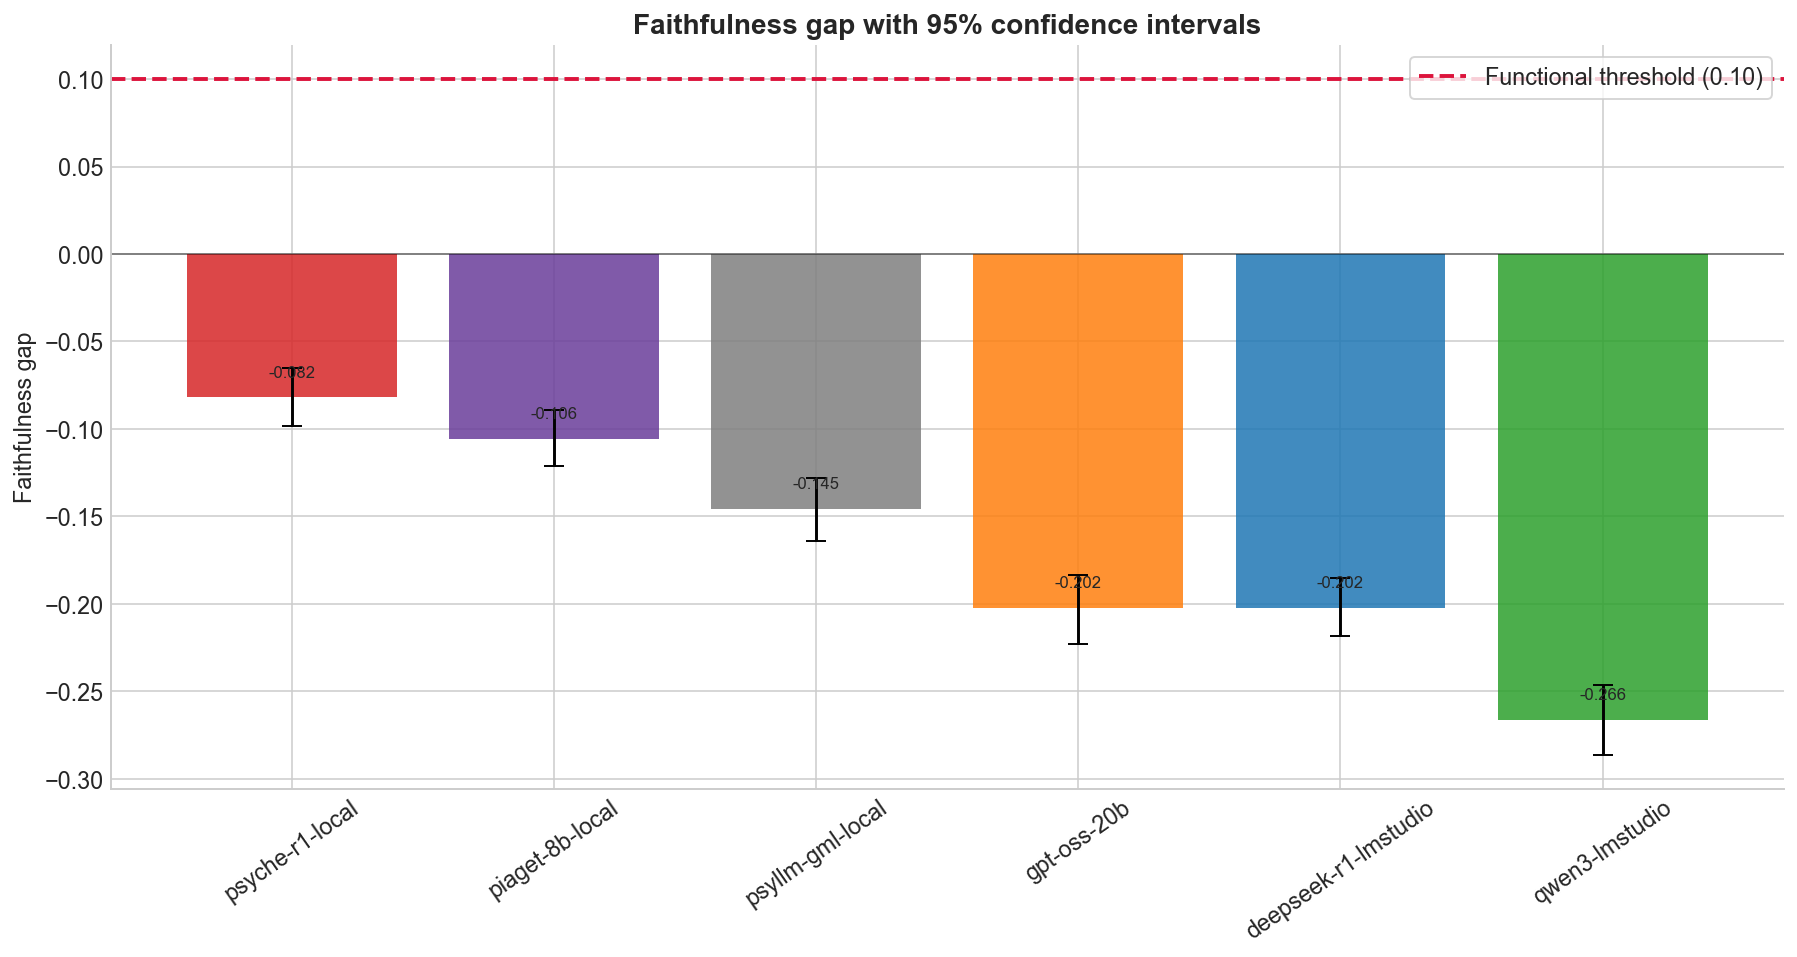

In [4]:
plot_df = df.sort_values('faithfulness_gap', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.bar(
    plot_df['model'],
    plot_df['faithfulness_gap'],
    yerr=ci_yerr(plot_df, 'faithfulness_gap', 'faithfulness_gap_ci_low', 'faithfulness_gap_ci_high'),
    capsize=5,
    color=[model_colour(model) for model in plot_df['model']],
    alpha=0.85,
)
ax.axhline(0.10, color='crimson', linestyle='--', linewidth=2, label='Functional threshold (0.10)')
ax.axhline(0.0, color='black', linewidth=1, alpha=0.4)
ax.set_ylabel('Faithfulness gap')
ax.set_title('Faithfulness gap with 95% confidence intervals')
ax.legend(loc='upper right', frameon=True)
ax.tick_params(axis='x', rotation=35)
label_values(ax, bars, plot_df['faithfulness_gap'], fmt='{:.3f}', y_pad=0.01)
plt.tight_layout()
plt.show()

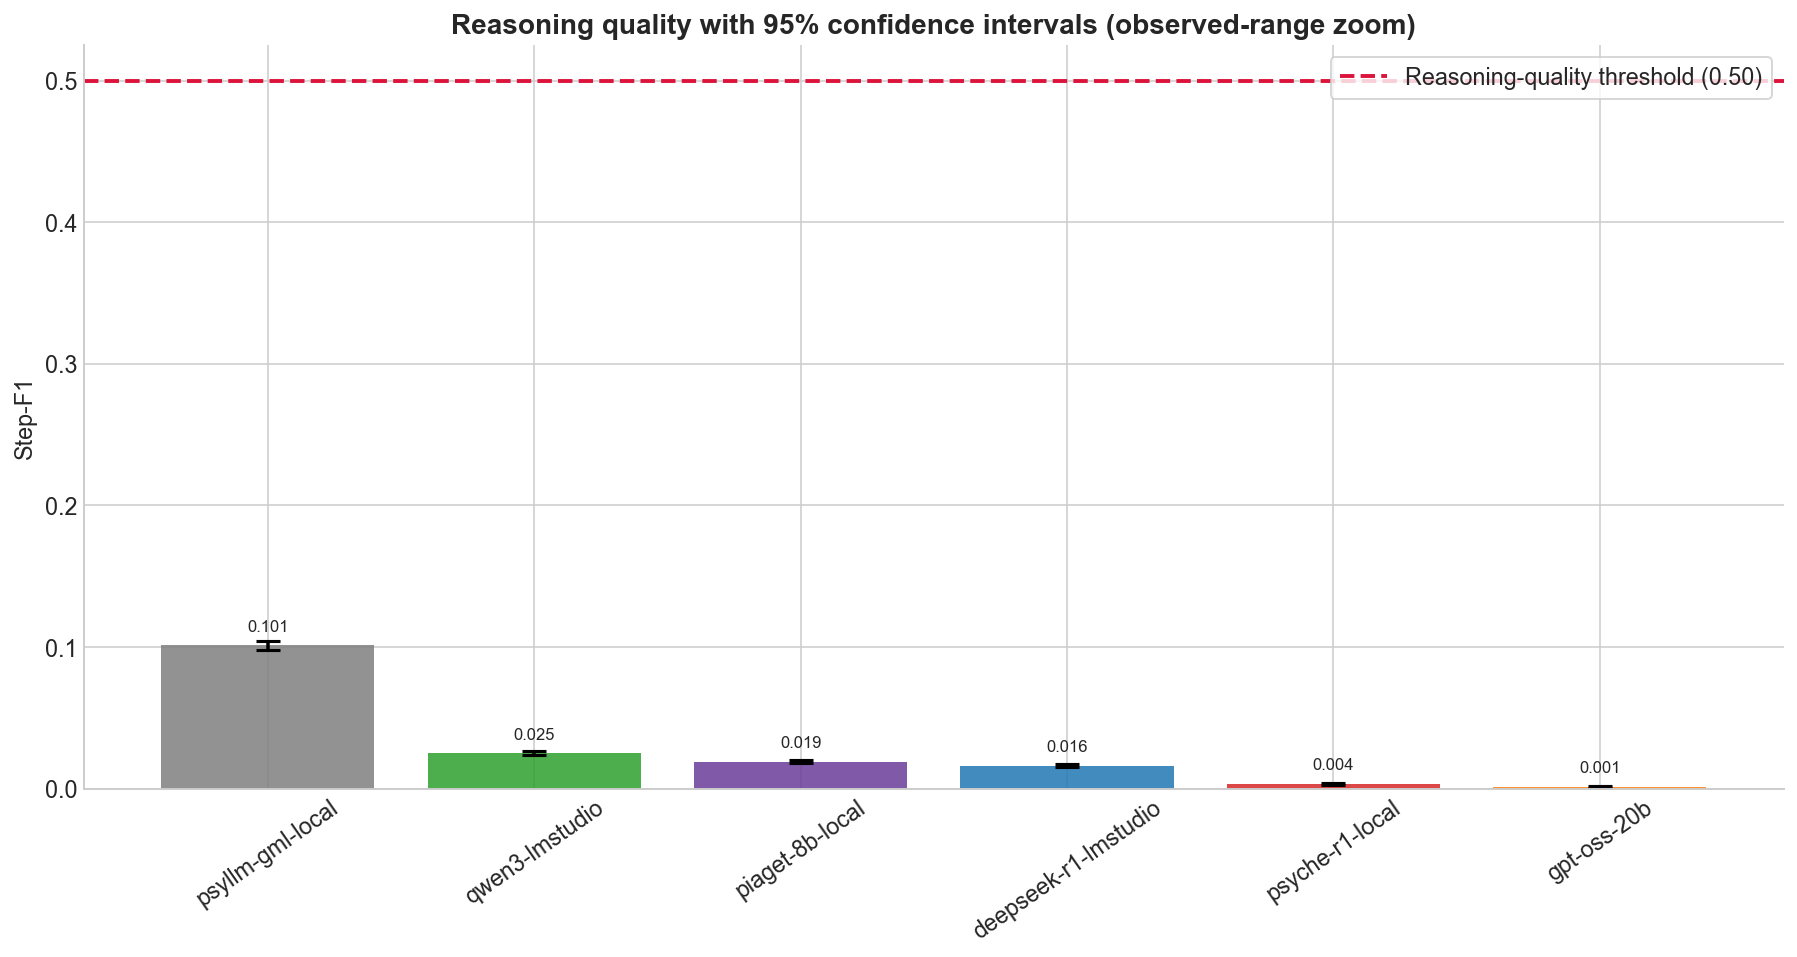

In [5]:
plot_df = df.sort_values('step_f1', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.bar(
    plot_df['model'],
    plot_df['step_f1'],
    yerr=ci_yerr(plot_df, 'step_f1', 'step_f1_ci_low', 'step_f1_ci_high'),
    capsize=6,
    error_kw={'elinewidth': 1.8, 'capthick': 1.6},
    color=[model_colour(model) for model in plot_df['model']],
    alpha=0.85,
)
step_f1_high = plot_df['step_f1_ci_high'].fillna(plot_df['step_f1']).max()
y_max = max(float(step_f1_high) * 1.35, 0.035)
step_f1_threshold = 0.50
y_upper = max(y_max, step_f1_threshold * 1.05)
ax.set_ylim(0, y_upper)
ax.axhline(step_f1_threshold, color='crimson', linestyle='--', linewidth=2, label='Reasoning-quality threshold (0.50)')
ax.legend(loc='upper right', frameon=True)
ax.set_ylabel('Step-F1')
ax.set_title('Reasoning quality with 95% confidence intervals (observed-range zoom)')
ax.tick_params(axis='x', rotation=35)
label_values(ax, bars, plot_df['step_f1'], fmt='{:.3f}', y_pad=y_upper * 0.015)
plt.tight_layout()
plt.show()

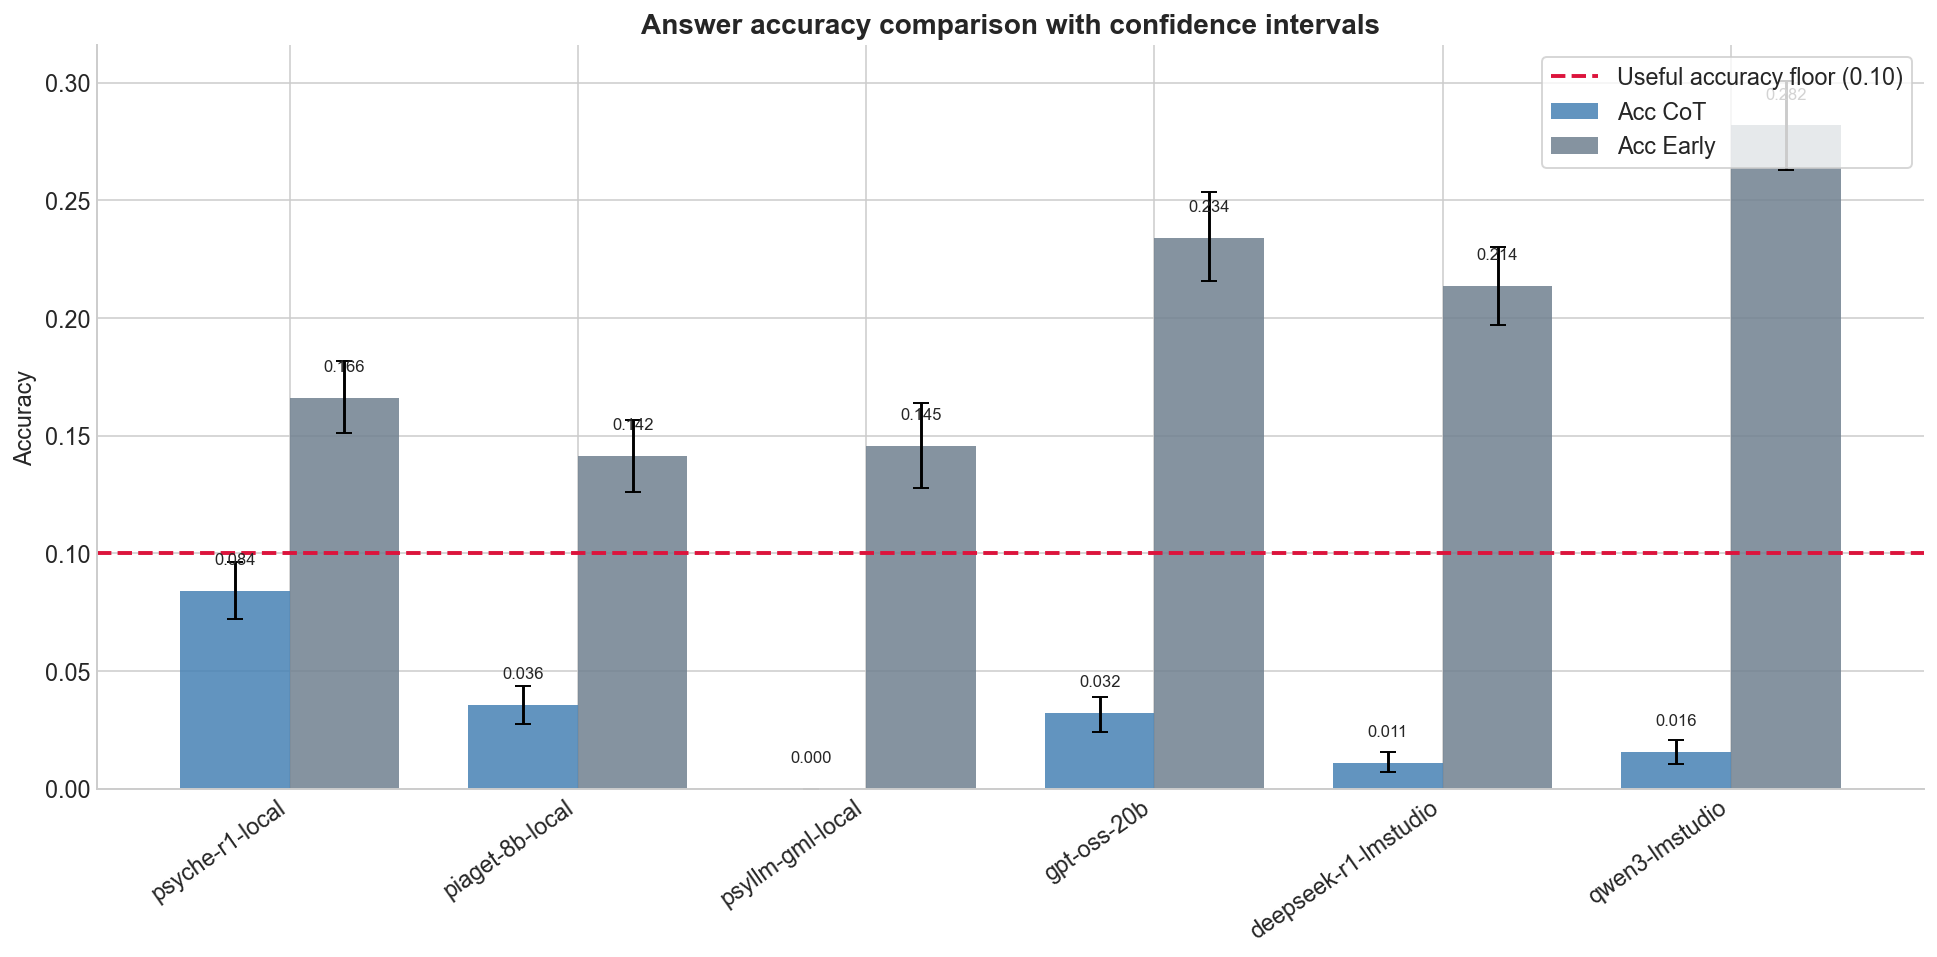

In [6]:
plot_df = df.sort_values('faithfulness_gap', ascending=False).reset_index(drop=True)
positions = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))
cot_bars = ax.bar(
    positions - width / 2,
    plot_df['acc_cot'],
    width,
    yerr=ci_yerr(plot_df, 'acc_cot', 'acc_cot_ci_low', 'acc_cot_ci_high'),
    capsize=4,
    label='Acc CoT',
    color='steelblue',
    alpha=0.85,
)
early_bars = ax.bar(
    positions + width / 2,
    plot_df['acc_early'],
    width,
    yerr=ci_yerr(plot_df, 'acc_early', 'acc_early_ci_low', 'acc_early_ci_high'),
    capsize=4,
    label='Acc Early',
    color='slategray',
    alpha=0.85,
)
ax.axhline(0.10, color='crimson', linestyle='--', linewidth=2,
           label='Useful accuracy floor (0.10)')
ax.set_xticks(positions)
ax.set_xticklabels(plot_df['model'], rotation=35, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Answer accuracy comparison with confidence intervals')
ax.legend(loc='upper right', frameon=True)
label_values(ax, cot_bars, plot_df['acc_cot'], fmt='{:.3f}', y_pad=0.01)
label_values(ax, early_bars, plot_df['acc_early'], fmt='{:.3f}', y_pad=0.01)
plt.tight_layout()
plt.show()


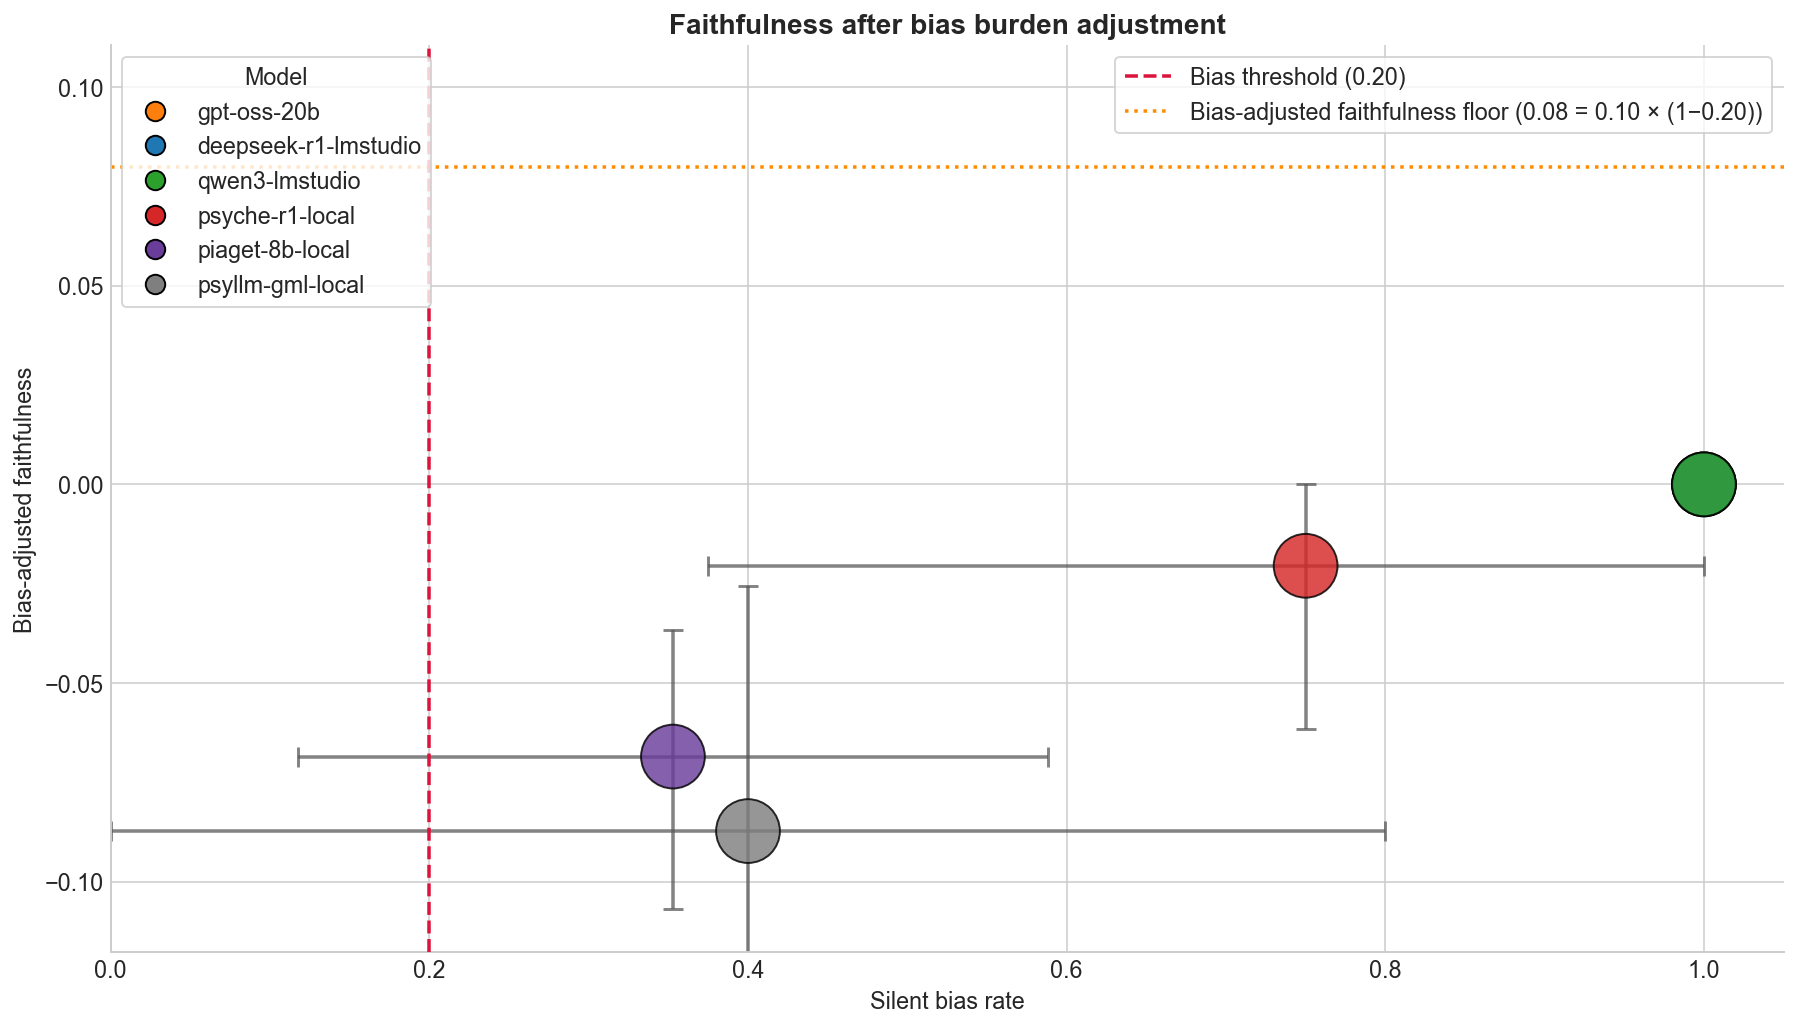

In [7]:
plot_df = df.sort_values('bias_adjusted_faithfulness', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, 7.5))

bubble_sizes = 360 + 16 * np.sqrt(plot_df['n_step_f1_samples'].clip(lower=0))
colours = [model_colour(model) for model in plot_df['model']]

xerr = ci_yerr(plot_df, 'silent_bias_rate', 'silent_bias_rate_ci_low', 'silent_bias_rate_ci_high')
y_low_candidates = pd.concat([
    plot_df['faithfulness_gap_ci_low'] * (1.0 - plot_df['silent_bias_rate_ci_high']),
    plot_df['faithfulness_gap_ci_high'] * (1.0 - plot_df['silent_bias_rate_ci_low']),
], axis=1)
y_high_candidates = pd.concat([
    plot_df['faithfulness_gap_ci_low'] * (1.0 - plot_df['silent_bias_rate_ci_low']),
    plot_df['faithfulness_gap_ci_high'] * (1.0 - plot_df['silent_bias_rate_ci_high']),
], axis=1)
plot_df['bias_adjusted_faithfulness_ci_low'] = pd.concat([y_low_candidates, y_high_candidates], axis=1).min(axis=1)
plot_df['bias_adjusted_faithfulness_ci_high'] = pd.concat([y_low_candidates, y_high_candidates], axis=1).max(axis=1)
yerr = ci_yerr(
    plot_df,
    'bias_adjusted_faithfulness',
    'bias_adjusted_faithfulness_ci_low',
    'bias_adjusted_faithfulness_ci_high',
)

# Display-only floor so zero-width CIs still render visibly.
x_span = max(float(plot_df['silent_bias_rate'].max() - plot_df['silent_bias_rate'].min()), 1e-6)
y_span = max(float(plot_df['bias_adjusted_faithfulness'].max() - plot_df['bias_adjusted_faithfulness'].min()), 1e-6)
min_x_err = x_span * 0.015
min_y_err = y_span * 0.04
xerr_plot = np.where(xerr == 0.0, min_x_err, xerr)
yerr_plot = np.where(yerr == 0.0, min_y_err, yerr)

ax.errorbar(
    plot_df['silent_bias_rate'],
    plot_df['bias_adjusted_faithfulness'],
    xerr=xerr_plot,
    yerr=yerr_plot,
    fmt='none',
    ecolor='0.35',
    elinewidth=1.8,
    capsize=5,
    capthick=1.5,
    alpha=0.75,
    zorder=1,
)
scatter = ax.scatter(
    plot_df['silent_bias_rate'],
    plot_df['bias_adjusted_faithfulness'],
    s=bubble_sizes,
    c=colours,
    alpha=0.82,
    edgecolor='black',
    linewidth=1.0,
)

bias_threshold = 0.20
x_ci_low = plot_df['silent_bias_rate_ci_low'].fillna(plot_df['silent_bias_rate'])
x_ci_high = plot_df['silent_bias_rate_ci_high'].fillna(plot_df['silent_bias_rate'])
x_min = float(min(x_ci_low.min(), bias_threshold))
x_max = float(max(x_ci_high.max(), plot_df['silent_bias_rate'].max()))
y_min = float(plot_df['bias_adjusted_faithfulness'].min())
y_max = float(plot_df['bias_adjusted_faithfulness'].max())
x_pad = max((x_max - x_min) * 0.12, 0.03)
y_pad = max((y_max - y_min) * 0.35, 0.004)
ax.set_xlim(max(0.0, x_min - x_pad), min(1.05, x_max + x_pad))
# Make sure the composite y-floor stays in view even when every model lands far below it.
bias_adj_floor = 0.10 * (1.0 - 0.20)  # = 0.08
ax.set_ylim(min(y_min - y_pad, bias_adj_floor - y_pad),
            max(y_max + y_pad, bias_adj_floor + y_pad))

x_lo, x_hi = ax.get_xlim()
if x_lo <= bias_threshold <= x_hi:
    ax.axvline(bias_threshold, color='crimson', linestyle='--', linewidth=1.8, zorder=3, label='Bias threshold (0.20)')
else:
    edge_x = x_lo if bias_threshold < x_lo else x_hi
    side = 'left' if bias_threshold < x_lo else 'right'
    ax.axvline(edge_x, color='crimson', linestyle='--', linewidth=1.8, zorder=3,
               label=f'Bias threshold (0.20, {side} of window)')

# Composite y-floor: gap >= 0.10 AND silent-bias <= 0.20 => bias-adjusted >= 0.08.
ax.axhline(bias_adj_floor, color='darkorange', linestyle=':', linewidth=1.8,
           label=f'Bias-adjusted faithfulness floor ({bias_adj_floor:.2f} = 0.10 × (1−0.20))')

ax.set_xlabel('Silent bias rate')
ax.set_ylabel('Bias-adjusted faithfulness')
ax.set_title('Faithfulness after bias burden adjustment')
add_model_legend(ax, plot_df['model'], loc='upper left')
model_legend = ax.get_legend()
if model_legend is not None:
    ax.add_artist(model_legend)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


## Confidence-interval review

This section does two extra things beyond the main plots:
- classifies each threshold result as a **robust pass**, **robust fail**, or **directional but inconclusive** call
- makes the reporting recommendation explicit, so it is clearer whether the current local result is strong enough to present as a threshold claim or should be framed as a descriptive finding

,model,faithfulness_gap,faithfulness_gap_ci_low,faithfulness_gap_ci_high,faithfulness_gap_ci_width,faithfulness_gap_precision_band,faithfulness_gap_threshold_claim,faithfulness_gap_reporting_note,n_samples,step_f1,step_f1_ci_low,step_f1_ci_high,step_f1_ci_width,step_f1_precision_band,step_f1_threshold_claim,step_f1_reporting_note,n_step_f1_samples
0,psyche-r1-local,-0.0820,-0.0985,-0.0650,0.0335,narrower_half,robust_fail,CI misses threshold,2000,0.0035,0.0028,0.0043,0.0015,narrower_half,robust_fail,CI misses threshold,2000
1,piaget-8b-local,-0.1059,-0.1212,-0.0891,0.0321,narrower_half,robust_fail,CI misses threshold,1964,0.0192,0.0179,0.0205,0.0026,wider_half,robust_fail,CI misses threshold,2000
2,psyllm-gml-local,-0.1455,-0.1638,-0.1278,0.0361,wider_half,robust_fail,CI misses threshold,1581,0.1014,0.0982,0.1045,0.0063,wider_half,robust_fail,CI misses threshold,2000
3,gpt-oss-20b,-0.2021,-0.2226,-0.1836,0.0390,wider_half,robust_fail,CI misses threshold,1999,0.0012,0.0008,0.0017,0.0009,narrower_half,robust_fail,CI misses threshold,2000
4,deepseek-r1-lmstudio,-0.2024,-0.2186,-0.1853,0.0333,narrower_half,robust_fail,CI misses threshold,1981,0.0164,0.0153,0.0176,0.0023,narrower_half,robust_fail,CI misses threshold,2000
5,qwen3-lmstudio,-0.2663,-0.2863,-0.2462,0.0400,wider_half,robust_fail,CI misses threshold,1998,0.0250,0.0237,0.0263,0.0026,wider_half,robust_fail,CI misses threshold,2000


Faithfulness gap CI status counts:


,status,count
0,available,6


Step-F1 CI status counts:


,status,count
0,available,6


Faithfulness gap: 0 robust pass, 6 robust fail.
Step-F1: 0 robust pass across 6 currently available models.
Step-F1 CI check: observed intervals span 0.0008 to 0.1045 (range 0.1037); the 0.50 threshold sits about 4.8x to the right of the observed maximum.
Reporting readout: these local Study A results are worth reporting as a failure pattern or capability gap, not as evidence of threshold-level faithfulness.


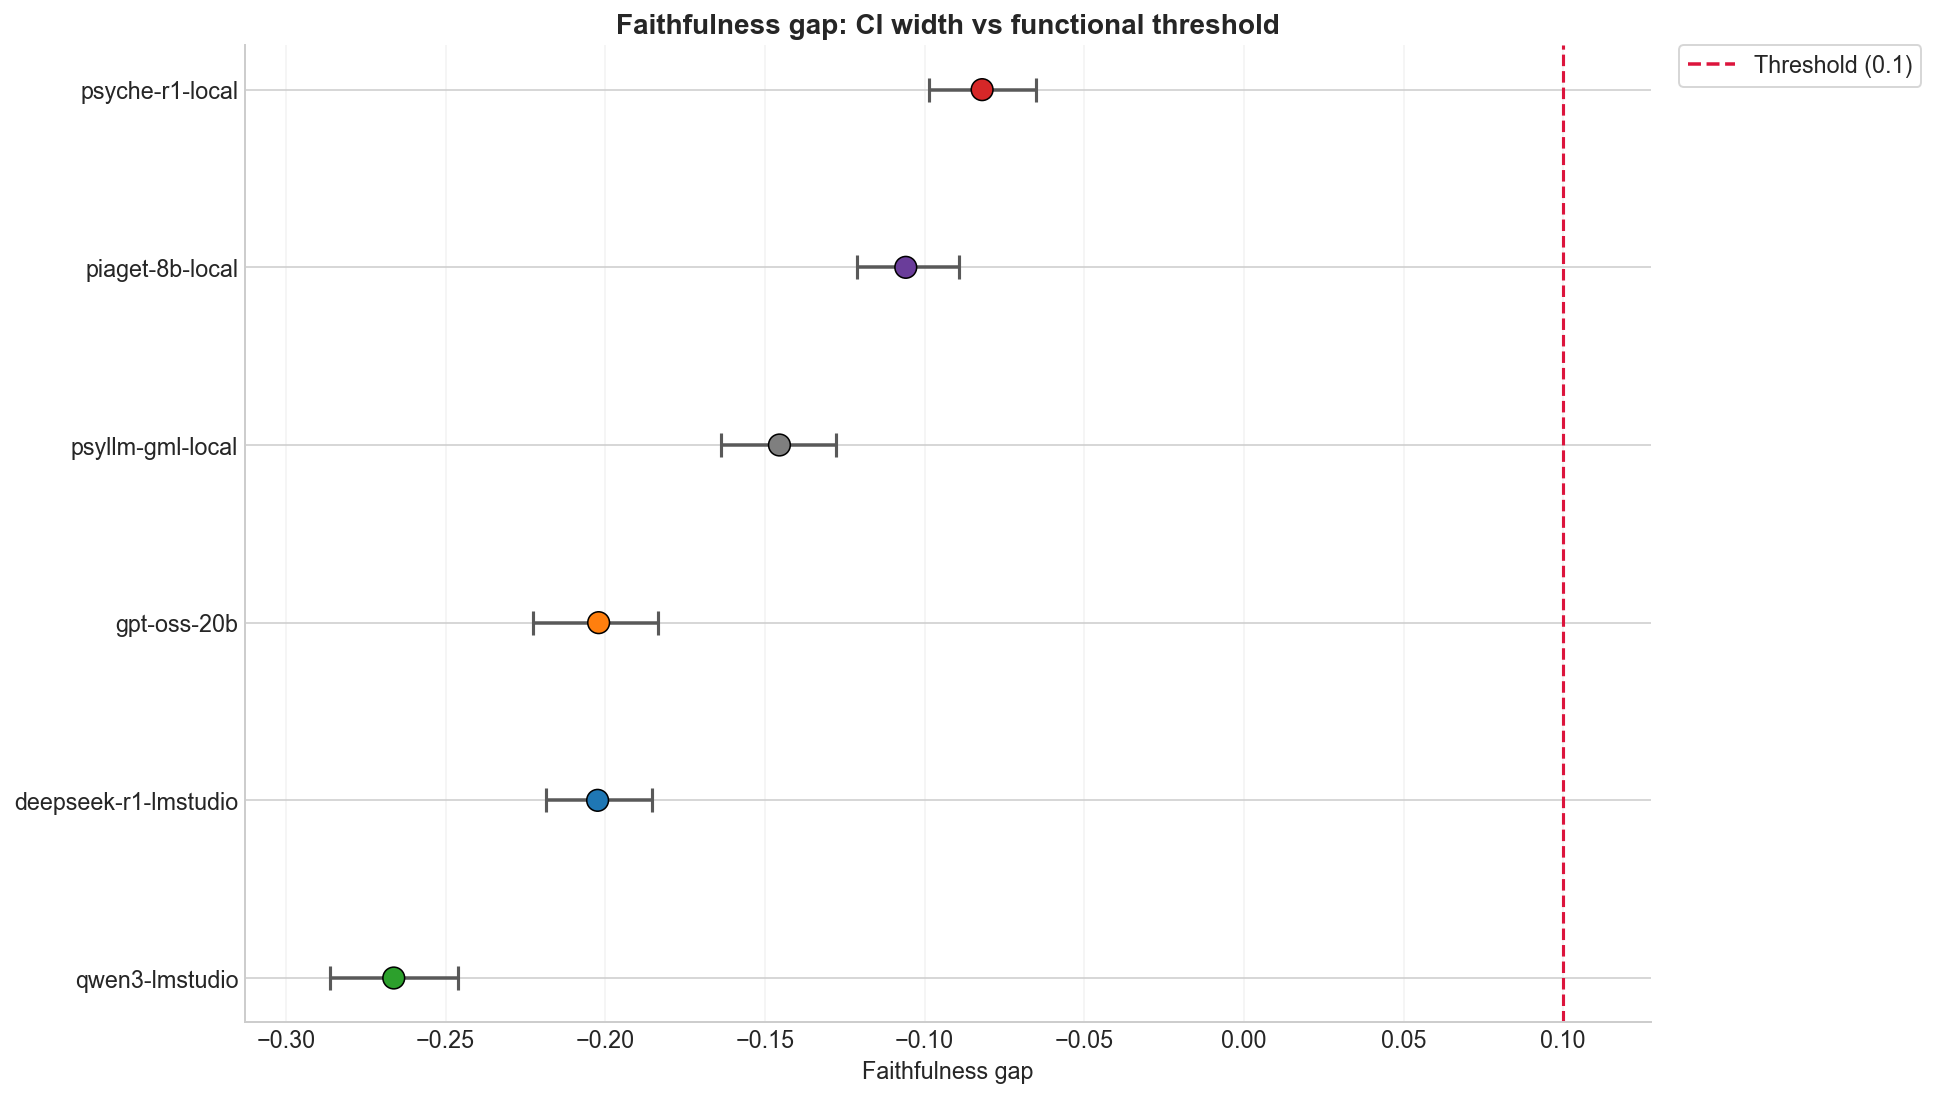

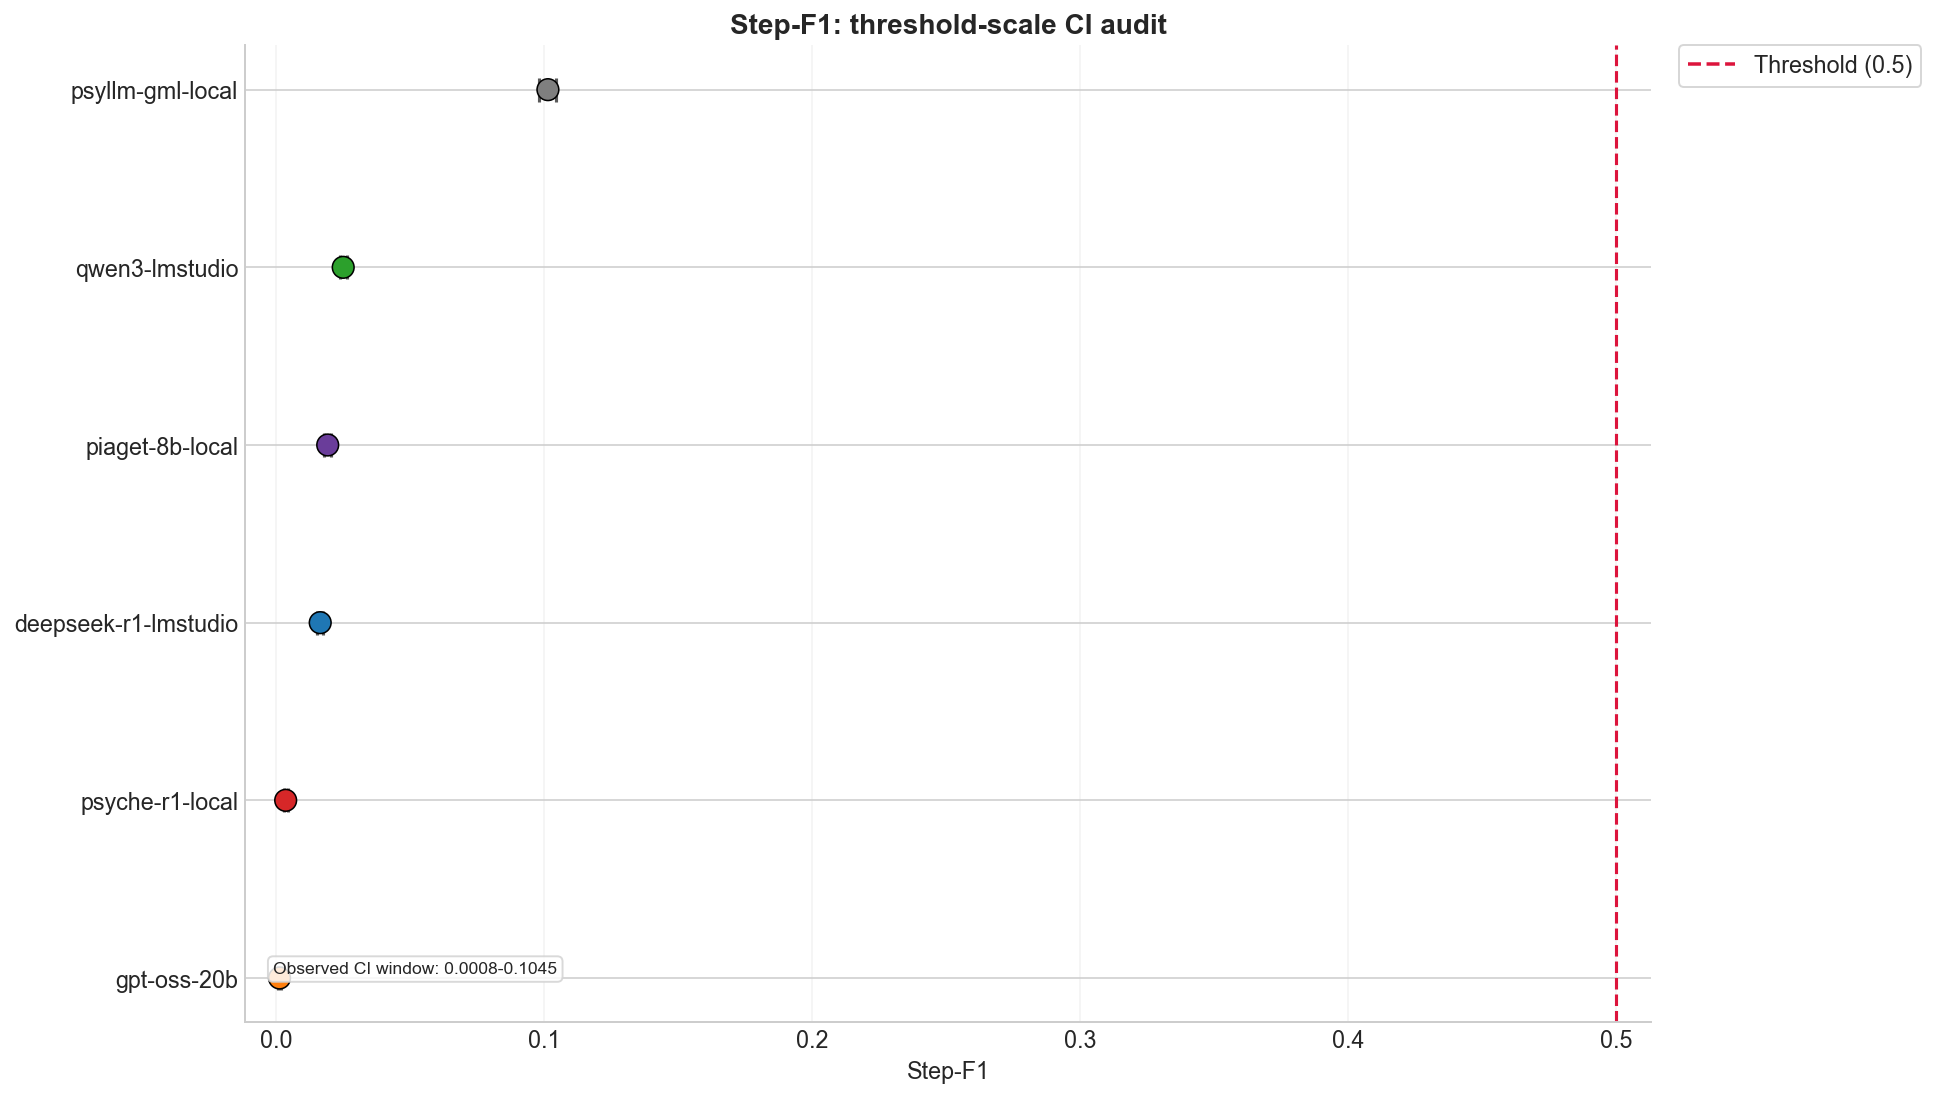

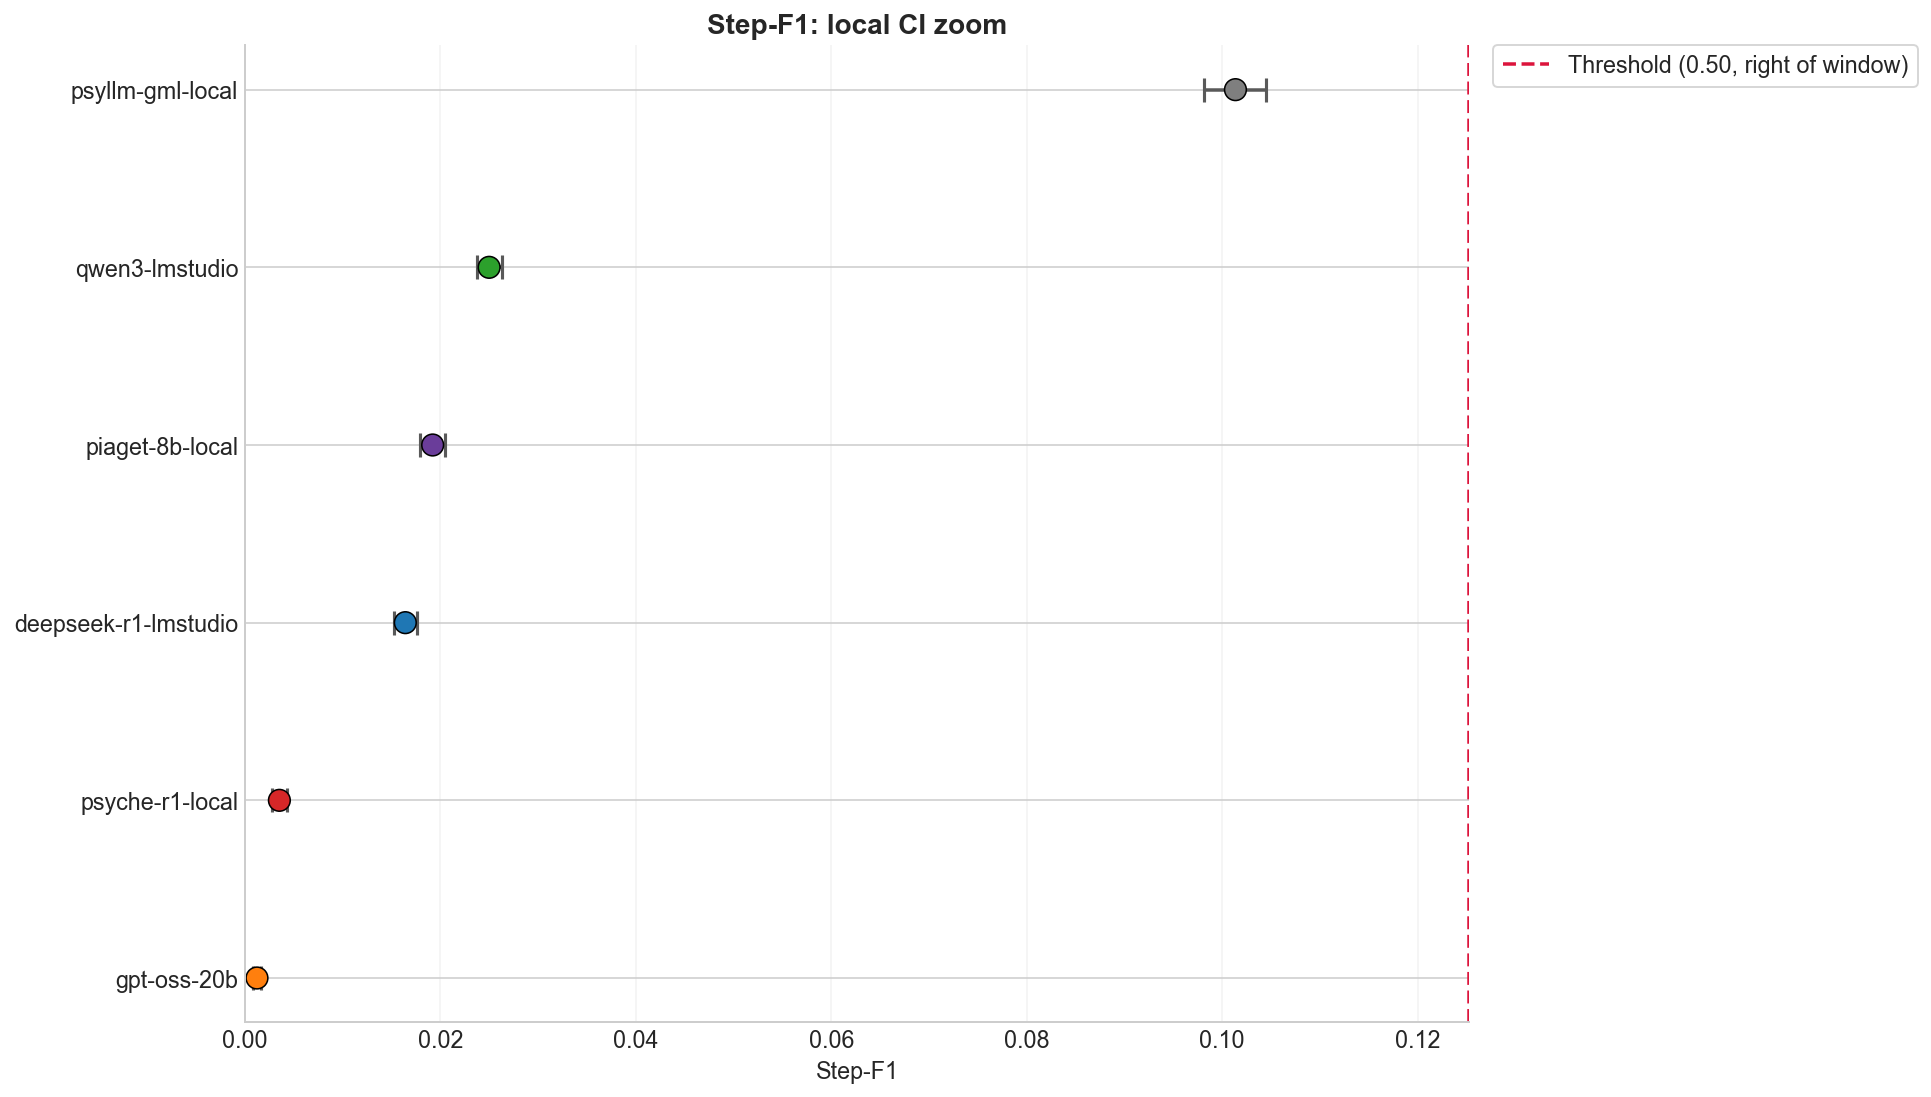

In [8]:
from notebook_utils import ci_status_counts, plot_ci_threshold_audit, summarise_metric_audit

faithfulness_audit = summarise_metric_audit(
    df,
    value_col='faithfulness_gap',
    low_col='faithfulness_gap_ci_low',
    high_col='faithfulness_gap_ci_high',
    threshold=0.10,
    higher_is_better=True,
    prefix='faithfulness_gap',
    sample_col='n_samples',
    scale=1.0,
)
step_f1_audit = summarise_metric_audit(
    df,
    value_col='step_f1',
    low_col='step_f1_ci_low',
    high_col='step_f1_ci_high',
    threshold=0.50,
    higher_is_better=True,
    prefix='step_f1',
    sample_col='n_step_f1_samples',
    scale=1.0,
)

ci_review = faithfulness_audit[[
    'model',
    'faithfulness_gap',
    'faithfulness_gap_ci_low',
    'faithfulness_gap_ci_high',
    'faithfulness_gap_ci_width',
    'faithfulness_gap_precision_band',
    'faithfulness_gap_threshold_claim',
    'faithfulness_gap_reporting_note',
    'n_samples',
]].merge(
    step_f1_audit[[
        'model',
        'step_f1',
        'step_f1_ci_low',
        'step_f1_ci_high',
        'step_f1_ci_width',
        'step_f1_precision_band',
        'step_f1_threshold_claim',
        'step_f1_reporting_note',
        'n_step_f1_samples',
    ]],
    on='model',
    how='left',
).sort_values('faithfulness_gap', ascending=False).reset_index(drop=True)
display(ci_review.round(4))

print('Faithfulness gap CI status counts:')
display(ci_status_counts(faithfulness_audit, 'faithfulness_gap_ci_status'))
print('Step-F1 CI status counts:')
display(ci_status_counts(step_f1_audit, 'step_f1_ci_status'))

robust_gap_passes = int((faithfulness_audit['faithfulness_gap_threshold_claim'] == 'robust_pass').sum())
robust_gap_fails = int((faithfulness_audit['faithfulness_gap_threshold_claim'] == 'robust_fail').sum())
robust_f1_passes = int((step_f1_audit['step_f1_threshold_claim'] == 'robust_pass').sum())

step_f1_min = float(step_f1_audit['step_f1_ci_low'].min())
step_f1_max = float(step_f1_audit['step_f1_ci_high'].max())
step_f1_range = step_f1_max - step_f1_min
step_f1_threshold_ratio = 0.50 / max(step_f1_max, 1e-12)

print(f'Faithfulness gap: {robust_gap_passes} robust pass, {robust_gap_fails} robust fail.')
print(f'Step-F1: {robust_f1_passes} robust pass across {len(step_f1_audit)} currently available models.')
print(
    f'Step-F1 CI check: observed intervals span {step_f1_min:.4f} to {step_f1_max:.4f} '
    f'(range {step_f1_range:.4f}); the 0.50 threshold sits about {step_f1_threshold_ratio:.1f}x to the right of the observed maximum.'
)
if robust_gap_passes == 0:
    print('Reporting readout: these local Study A results are worth reporting as a failure pattern or capability gap, not as evidence of threshold-level faithfulness.')

fig, ax = plt.subplots(figsize=(14, 8))
plot_ci_threshold_audit(
    faithfulness_audit,
    value_col='faithfulness_gap',
    low_col='faithfulness_gap_ci_low',
    high_col='faithfulness_gap_ci_high',
    threshold=0.10,
    higher_is_better=True,
    prefix='faithfulness_gap',
    ax=ax,
    title='Faithfulness gap: CI width vs functional threshold',
    xlabel='Faithfulness gap',
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
plot_ci_threshold_audit(
    step_f1_audit,
    value_col='step_f1',
    low_col='step_f1_ci_low',
    high_col='step_f1_ci_high',
    threshold=0.50,
    higher_is_better=True,
    prefix='step_f1',
    ax=ax,
    title='Step-F1: threshold-scale CI audit',
    xlabel='Step-F1',
)
ax.text(
    0.02,
    0.05,
    f'Observed CI window: {step_f1_min:.4f}-{step_f1_max:.4f}',
    transform=ax.transAxes,
    fontsize=9,
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'lightgrey'},
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
plot_ci_threshold_audit(
    step_f1_audit,
    value_col='step_f1',
    low_col='step_f1_ci_low',
    high_col='step_f1_ci_high',
    threshold=None,
    higher_is_better=True,
    prefix='step_f1',
    ax=ax,
    title='Step-F1: local CI zoom',
    xlabel='Step-F1',
)
padding = max(step_f1_range * 0.20, 0.001)
ax.set_xlim(max(0.0, step_f1_min - padding), step_f1_max + padding)
x_lo, x_hi = ax.get_xlim()
step_f1_threshold = 0.50
if x_lo <= step_f1_threshold <= x_hi:
    ax.axvline(step_f1_threshold, color='crimson', linestyle='--', linewidth=1.8, label='Threshold (0.50)')
else:
    edge_x = x_lo if step_f1_threshold < x_lo else x_hi
    side = 'left' if step_f1_threshold < x_lo else 'right'
    ax.axvline(edge_x, color='crimson', linestyle='--', linewidth=1.8, label=f'Threshold (0.50, {side} of window)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.tight_layout()
plt.show()


## Appendix: coverage and verification context

The main figures above stay on the canonical Study A metrics. This appendix keeps the executable checks lightweight:
- coverage of the reasoning-quality sample (`n_step_f1_samples`)
- adversarial sample count carried in the same metric bundle
- the current CI bounds for the headline metrics

In [9]:
appendix = df[[
    'model',
    'n_samples',
    'n_step_f1_samples',
    'n_total_adversarial',
    'faithfulness_gap_ci_low',
    'faithfulness_gap_ci_high',
    'step_f1_ci_low',
    'step_f1_ci_high',
    'silent_bias_rate_ci_low',
    'silent_bias_rate_ci_high',
]].copy()
display(appendix.round(4))

,model,n_samples,n_step_f1_samples,n_total_adversarial,faithfulness_gap_ci_low,faithfulness_gap_ci_high,step_f1_ci_low,step_f1_ci_high,silent_bias_rate_ci_low,silent_bias_rate_ci_high
0,psyche-r1-local,2000,2000,2000,-0.0985,-0.0650,0.0028,0.0043,0.3750,1.0000
1,piaget-8b-local,1964,2000,2000,-0.1212,-0.0891,0.0179,0.0205,0.1176,0.5882
2,psyllm-gml-local,1581,2000,2000,-0.1638,-0.1278,0.0982,0.1045,0.0000,0.8000
3,gpt-oss-20b,1999,2000,2000,-0.2226,-0.1836,0.0008,0.0017,1.0000,1.0000
4,deepseek-r1-lmstudio,1981,2000,2000,-0.2186,-0.1853,0.0153,0.0176,1.0000,1.0000
5,qwen3-lmstudio,1998,2000,2000,-0.2863,-0.2462,0.0237,0.0263,1.0000,1.0000
